In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [3]:
# Finding each customer's first purchase
first_purchase = (
    df.groupby("customer_id")["order_date"]
      .min()
      .reset_index()
)

first_purchase.head()

,customer_id,order_date
0,C0001,2025-01-16 16:46:45.681136227
1,C0002,2025-02-15 11:05:24.784956991
2,C0003,2025-01-01 15:41:56.903380676
3,C0004,2025-02-05 23:27:09.685937187
4,C0005,2025-05-30 21:43:10.358071614


In [4]:
# Renaming the column:
first_purchase = first_purchase.rename(
    columns={
        "order_date": "first_purchase_date"
    }
)

In [5]:
# Creating cohort month
first_purchase["cohort_month"] = (
    first_purchase["first_purchase_date"]
    .dt.to_period("M")
)

In [6]:
first_purchase.head()

,customer_id,first_purchase_date,cohort_month
0,C0001,2025-01-16 16:46:45.681136227,2025-01
1,C0002,2025-02-15 11:05:24.784956991,2025-02
2,C0003,2025-01-01 15:41:56.903380676,2025-01
3,C0004,2025-02-05 23:27:09.685937187,2025-02
4,C0005,2025-05-30 21:43:10.358071614,2025-05


In [7]:
# Adding cohort month to every order
df = df.merge(
    first_purchase[
        ["customer_id", "cohort_month"]
    ],
    on="customer_id",
    how="left"
)

In [8]:
df[
    [
        "customer_id",
        "order_date",
        "cohort_month"
    ]
].head(10)

,customer_id,order_date,cohort_month
0,C0017,2025-01-01 00:00:00.000000000,2025-01
1,C0056,2025-01-01 02:36:59.483896779,2025-01
2,C0182,2025-01-01 05:13:58.967793558,2025-01
3,C0144,2025-01-01 07:50:58.451690338,2025-01
4,C0319,2025-01-01 10:27:57.935587117,2025-01
5,C0358,2025-01-01 13:04:57.419483896,2025-01
6,C0003,2025-01-01 15:41:56.903380676,2025-01
7,C0202,2025-01-01 18:18:56.387277455,2025-01
8,C0101,2025-01-01 20:55:55.871174234,2025-01
9,C0163,2025-01-01 23:32:55.355071014,2025-01


In [9]:
# Creating order month
df["order_month"] = (
    df["order_date"]
    .dt.to_period("M")
)

In [10]:
# Calculating months since first purchase
df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    +
    (df["order_month"].dt.month - df["cohort_month"].dt.month)
)

In [11]:
df[
    [
        "customer_id",
        "cohort_month",
        "order_month",
        "cohort_index"
    ]
].head(20)

,customer_id,cohort_month,order_month,cohort_index
0,C0017,2025-01,2025-01,0
1,C0056,2025-01,2025-01,0
2,C0182,2025-01,2025-01,0
3,C0144,2025-01,2025-01,0
4,C0319,2025-01,2025-01,0
5,C0358,2025-01,2025-01,0
6,C0003,2025-01,2025-01,0
7,C0202,2025-01,2025-01,0
8,C0101,2025-01,2025-01,0
9,C0163,2025-01,2025-01,0


In [12]:
# unique customers
cohort_data = (
    df.groupby(
        ["cohort_month", "cohort_index"]
    )["customer_id"]
    .nunique()
    .reset_index()
)

In [13]:
cohort_data.head(20)

,cohort_month,cohort_index,customer_id
0,2025-01,0,212
1,2025-01,1,94
2,2025-01,2,94
3,2025-01,3,97
4,2025-01,4,103
5,2025-01,5,97
6,2025-01,6,88
7,2025-01,7,94
8,2025-01,8,89
9,2025-01,9,99


In [14]:
# Creating the retention matrix
cohort_matrix = cohort_data.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

In [15]:
cohort_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
cohort_month,,,,,,,,,,,,,,,,,,
2025-01,212.0,94.0,94.0,97.0,103.0,97.0,88.0,94.0,89.0,99.0,90.0,86.0,89.0,87.0,93.0,94.0,87.0,90.0
2025-02,111.0,49.0,45.0,30.0,44.0,51.0,45.0,49.0,55.0,41.0,48.0,44.0,42.0,56.0,52.0,51.0,42.0,NaN
2025-03,78.0,32.0,32.0,36.0,40.0,30.0,38.0,29.0,29.0,44.0,35.0,34.0,37.0,27.0,36.0,35.0,NaN,NaN
2025-04,44.0,20.0,17.0,19.0,21.0,17.0,19.0,17.0,22.0,21.0,17.0,17.0,14.0,21.0,24.0,NaN,NaN,NaN
2025-05,26.0,12.0,10.0,10.0,11.0,10.0,12.0,12.0,12.0,11.0,8.0,6.0,12.0,7.0,NaN,NaN,NaN,NaN
2025-06,8.0,2.0,7.0,3.0,5.0,4.0,3.0,6.0,3.0,4.0,5.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN
2025-07,7.0,5.0,2.0,2.0,NaN,4.0,5.0,3.0,3.0,4.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,5.0,NaN,2.0,2.0,4.0,4.0,2.0,NaN,3.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,5.0,4.0,3.0,1.0,2.0,2.0,1.0,1.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Converting customer counts into retention %
retention_matrix = (
    cohort_matrix
    .div(cohort_matrix.iloc[:, 0], axis=0)
    * 100
)

In [17]:
retention_matrix = retention_matrix.round(2)

In [18]:
retention_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
cohort_month,,,,,,,,,,,,,,,,,,
2025-01,100.0,44.34,44.34,45.75,48.58,45.75,41.51,44.34,41.98,46.70,42.45,40.57,41.98,41.04,43.87,44.34,41.04,42.45
2025-02,100.0,44.14,40.54,27.03,39.64,45.95,40.54,44.14,49.55,36.94,43.24,39.64,37.84,50.45,46.85,45.95,37.84,NaN
2025-03,100.0,41.03,41.03,46.15,51.28,38.46,48.72,37.18,37.18,56.41,44.87,43.59,47.44,34.62,46.15,44.87,NaN,NaN
2025-04,100.0,45.45,38.64,43.18,47.73,38.64,43.18,38.64,50.00,47.73,38.64,38.64,31.82,47.73,54.55,NaN,NaN,NaN
2025-05,100.0,46.15,38.46,38.46,42.31,38.46,46.15,46.15,46.15,42.31,30.77,23.08,46.15,26.92,NaN,NaN,NaN,NaN
2025-06,100.0,25.00,87.50,37.50,62.50,50.00,37.50,75.00,37.50,50.00,62.50,75.00,37.50,NaN,NaN,NaN,NaN,NaN
2025-07,100.0,71.43,28.57,28.57,NaN,57.14,71.43,42.86,42.86,57.14,71.43,71.43,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,NaN,40.00,40.00,80.00,80.00,40.00,NaN,60.00,40.00,20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,80.00,60.00,20.00,40.00,40.00,20.00,20.00,20.00,60.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


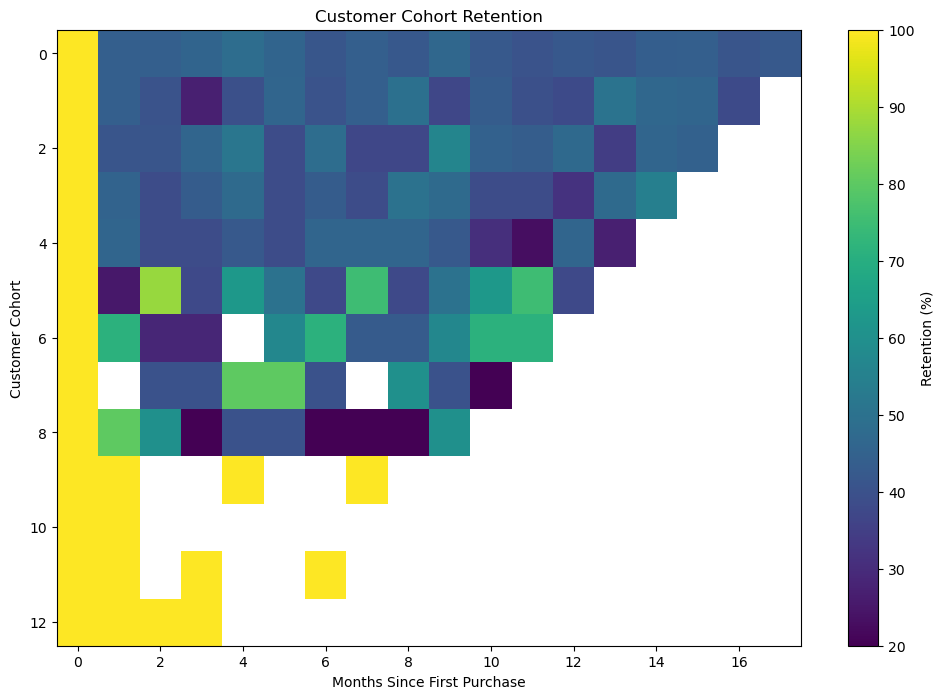

In [19]:
# Visualizing the retention matrix
plt.figure(figsize=(12, 8))

plt.imshow(
    retention_matrix,
    aspect="auto"
)

plt.colorbar(label="Retention (%)")

plt.title("Customer Cohort Retention")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort")

plt.show()

In [20]:
# Month 1 retention
month_1_retention = (
    retention_matrix[1]
    .dropna()
    .mean()
)

print(
    "Average Month 1 Retention:",
    round(month_1_retention, 2),
    "%"
)

Average Month 1 Retention: 66.46 %


In [21]:
# Month 3 retention 
month_3_retention = (
    retention_matrix[3]
    .dropna()
    .mean()
)

print(
    "Average Month 3 Retention:",
    round(month_3_retention, 2),
    "%"
)

Average Month 3 Retention: 47.88 %


In [22]:
# strongest cohort
month_1_by_cohort = (
    retention_matrix[1]
    .dropna()
    .sort_values(ascending=False)
)

month_1_by_cohort

cohort_month
2025-10    100.00
2025-11    100.00
2025-12    100.00
2026-01    100.00
2025-09     80.00
2025-07     71.43
2025-05     46.15
2025-04     45.45
2025-01     44.34
2025-02     44.14
2025-03     41.03
2025-06     25.00
Freq: M, Name: 1, dtype: float64

In [23]:
# weakest cohort
weakest_cohort = (
    retention_matrix[1]
    .dropna()
    .idxmin()
)

weakest_retention = (
    retention_matrix.loc[
        weakest_cohort,
        1
    ]
)

print("Weakest Cohort:", weakest_cohort)
print(
    "Month 1 Retention:",
    round(weakest_retention, 2),
    "%"
)

Weakest Cohort: 2025-06
Month 1 Retention: 25.0 %


In [24]:
# Creating a retention summary
retention_summary = pd.DataFrame({
    "Metric": [
        "Month 1 Retention",
        "Month 3 Retention"
    ],
    "Retention_Percentage": [
        month_1_retention,
        month_3_retention
    ]
})

In [25]:
retention_summary[
    "Retention_Percentage"
] = retention_summary[
    "Retention_Percentage"
].round(2)

In [26]:
# Save
retention_matrix.to_csv(
    "../data/processed/cohort_retention_matrix.csv"
)

In [27]:
retention_summary.to_csv(
    "../data/processed/retention_summary.csv",
    index=False
)

#  Day 12 — Cohort Retention Insights

## Cohort Analysis

Customers were grouped into cohorts based on the month
of their first purchase.

This allows DataPulse to compare how customer engagement
changes after acquisition.

## Month 1 Retention

Average Month 1 retention:
66.46%

This indicates that approximately 66.46% of customers
from a typical cohort made another purchase during the
month following their first purchase.

## Month 3 Retention

Average Month 3 retention:
47.88%

The decline from Month 1 to Month 3 suggests that
customer engagement declines over time.

## Strongest Cohort

The cohort with the strongest Month 1 retention was:
2025-10

Retention:
100%

## Weakest Cohort

The cohort with the weakest Month 1 retention was:
2025-06

Retention:
25%

## Key Business Insight

The cohort analysis indicates that customer retention
changes over time rather than remaining constant.

The most important observation from today's analysis is:

Customer retention decreases over time, falling from 66.46% in Month 1 to 47.88% by Month 3, indicating that retaining customers beyond the initial repeat purchase is a key challenge.

## Business Recommendation

DataPulse should monitor customer retention by acquisition
cohort rather than relying only on overall customer metrics.

Understanding which cohorts retain customers more
successfully can help the business investigate differences
in acquisition channels, promotions, products, or customer
experiences.

## Analytical Limitation

The current DataPulse dataset is synthetic and generated
for analytics practice. Therefore, retention patterns
should not be interpreted as real-world business behavior.
The analysis demonstrates the analytical methodology that
could be applied to actual business data.